In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import os

In [10]:
def display(images, n = 10, size =(20, 3),cmap = "gray_r", as_type="float32", save_to=None):

    if images.max() > 1.0:
       images = images / 255.0
    elif images.min() < 0.0:
      images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
          _=plt.subplot(1, n, i + 1)
          plt.imshow(images[i].astype(as_type), cmap=cmap)
          plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()


In [11]:
IMAGE_SIZE = 32
CHANNELS = 3
BATCH_SIZE = 144
BUFFER_SIZE = 1000
VALIDATION_SPLIT = 0.2
EMBEDDING_DIM = 2
EPOCHS = 20
BETA = 5.0
LEARNING_RATE = 0.005
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


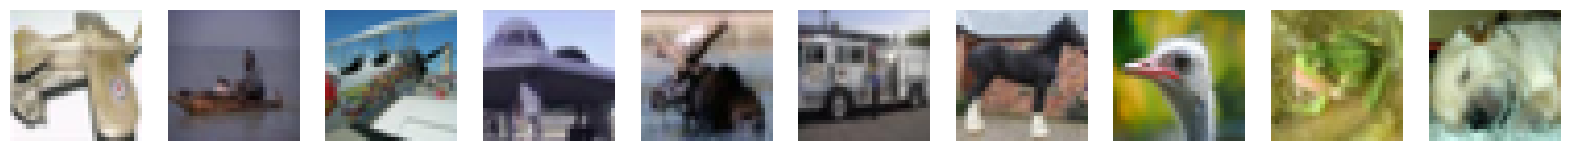

[0 8 0 0 4 9 7 2 6 5]


In [12]:
# I use this cell so i can download the data and display 10 images to see if it's correct
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.CIFAR10(root="data", train=False, transform=transform, download=True)


train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False)

 #display some images
images, labels = next(iter(train_loader))
images = images.permute(0, 2, 3, 1).numpy()
labels = labels.numpy()

images = (images * 0.5 + 0.5) * 255.0

display(images[:10])
print(labels[:10])

In [13]:
class Encoder_part(nn.Module): #this is the encoder part
    def __init__(self, embedding_dim=2):
        super(Encoder_part, self).__init__()

        # CIFAR-10: input size (3, 32, 32)
        self.conv1 = nn.Conv2d(3, 32, 3, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1)
        self.conv4 = nn.Conv2d(128, 256, 3, 1, 1)
        self.conv5 = nn.Conv2d(256, 512, 3, 1, 1)

        self.flatten_size = 512 * 4 * 4
        self.fc_mean = nn.Linear(self.flatten_size, embedding_dim)
        self.fc_log_var = nn.Linear(self.flatten_size, embedding_dim)


        self.init_weights()

    def init_weights(self):

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)   # Xavier initialization
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = x.view(x.size(0), -1)

        z_mean = self.fc_mean(x)
        z_log_var = self.fc_log_var(x)
        return z_mean, z_log_var

    def sampling(self, z_mean, z_log_var):
        batch = z_mean.size(0)
        dim = z_mean.size(1)
        epsilon = torch.randn(batch, dim).to(z_mean.device)
        return z_mean + torch.exp(0.5 * z_log_var) * epsilon


In [14]:
class Decoder_part(nn.Module): #the decoder part , use of the same number of layers
    def __init__(self, embedding_dim=2):
        super(Decoder_part, self).__init__()

        self.fc = nn.Linear(embedding_dim, 512 * 4 * 4)

        self.deconv1 = nn.ConvTranspose2d(512, 256, 3, 1, 1)
        self.deconv2 = nn.ConvTranspose2d(256, 128, 3, 1, 1)
        self.deconv3 = nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1)
        self.deconv4 = nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1)
        self.deconv5 = nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1)

        self.bn1 = nn.BatchNorm2d(256)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(64)
        self.bn4 = nn.BatchNorm2d(32)
        self.bn5 = nn.BatchNorm2d(16)

        self.conv_out = nn.Conv2d(16, 3, 3, 1, 1)

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 512, 4, 4)

        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = F.relu(self.bn3(self.deconv3(x)))
        x = F.relu(self.bn4(self.deconv4(x)))
        x = F.relu(self.bn5(self.deconv5(x)))

        x = torch.tanh(self.conv_out(x))  # Output in [-1, 1]
        return x

In [15]:
class VAE(nn.Module):
    def __init__(self, encoder, decoder, beta=1.0):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.encoder.sampling(z_mean, z_log_var)
        reconstruction = self.decoder(z)
        return z_mean, z_log_var, reconstruction

    def loss(self, x, reconstruction, z_mean, z_log_var):
        # Reconstruction loss (mean squared error)
        reconstruction_loss = F.mse_loss(reconstruction, x, reduction='sum')

        # KL Divergence loss formula
        kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())

        # to get the total loss
        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss


In [16]:
#let's train the model now

# Training
encoder = Encoder_part(embedding_dim=EMBEDDING_DIM).to(device)
decoder = Decoder_part(embedding_dim=EMBEDDING_DIM).to(device)
vae = VAE(encoder, decoder, beta = BETA).to(device)


optimizer = torch.optim.Adam(vae.parameters(), lr=LEARNING_RATE)


os.makedirs('./models', exist_ok=True)
os.makedirs('./logs', exist_ok=True)

print("\nStarting training...")
best_loss = float('inf')

for epoch in range(EPOCHS):
    # Training
    vae.train()
    train_loss = 0
    train_recon_loss = 0
    train_kl_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        optimizer.zero_grad()
        z_mean, z_log_var, reconstruction = vae(data)
        loss, recon_loss, kl_loss = vae.loss(data, reconstruction, z_mean, z_log_var)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_recon_loss += recon_loss.item()
        train_kl_loss += kl_loss.item()

    train_loss /= len(train_loader)
    train_recon_loss /= len(train_loader)
    train_kl_loss /= len(train_loader)


    vae.eval()
    val_loss = 0
    val_recon_loss = 0
    val_kl_loss = 0

    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            z_mean, z_log_var, reconstruction = vae(data)
            loss, recon_loss, kl_loss = vae.loss(data, reconstruction, z_mean, z_log_var)

            val_loss += loss.item()
            val_recon_loss += recon_loss.item()
            val_kl_loss += kl_loss.item()

    val_loss /= len(test_loader)
    val_recon_loss /= len(test_loader)
    val_kl_loss /= len(test_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train - Loss: {train_loss:.4f}, Recon: {train_recon_loss:.4f}, KL: {train_kl_loss:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, Recon: {val_recon_loss:.4f}, KL: {val_kl_loss:.4f}")

    # to save the best model
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save({
            'vae_state_dict': vae.state_dict(),
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        }, './models/checkpoint.pth')

# To save the final models
torch.save(vae.state_dict(), './models/vae.pth')
torch.save(encoder.state_dict(), './models/encoder.pth')
torch.save(decoder.state_dict(), './models/decoder.pth')
print("\nModels saved!")


Starting training...
Epoch 1/20
  Train - Loss: 84678.9563, Recon: 76024.7328, KL: 1730.8446
  Val   - Loss: 70003.7549, Recon: 67278.2626, KL: 545.0984
Epoch 2/20
  Train - Loss: 69264.8717, Recon: 66310.4285, KL: 590.8886
  Val   - Loss: 68259.6926, Recon: 65280.3618, KL: 595.8662
Epoch 3/20
  Train - Loss: 68901.8439, Recon: 65868.4996, KL: 606.6689
  Val   - Loss: 69693.6257, Recon: 66342.2390, KL: 670.2774
Epoch 4/20
  Train - Loss: 68749.2185, Recon: 65590.8926, KL: 631.6652
  Val   - Loss: 69247.0103, Recon: 66006.0033, KL: 648.2014
Epoch 5/20
  Train - Loss: 68773.6870, Recon: 65538.9084, KL: 646.9557
  Val   - Loss: 69199.0238, Recon: 66079.3844, KL: 623.9280
Epoch 6/20
  Train - Loss: 68997.8375, Recon: 65691.4696, KL: 661.2736
  Val   - Loss: 68408.3689, Recon: 65100.1443, KL: 661.6450
Epoch 7/20
  Train - Loss: 68432.1103, Recon: 65119.4654, KL: 662.5290
  Val   - Loss: 70384.3562, Recon: 67386.3371, KL: 599.6038
Epoch 8/20
  Train - Loss: 67993.6605, Recon: 64632.7170, KL

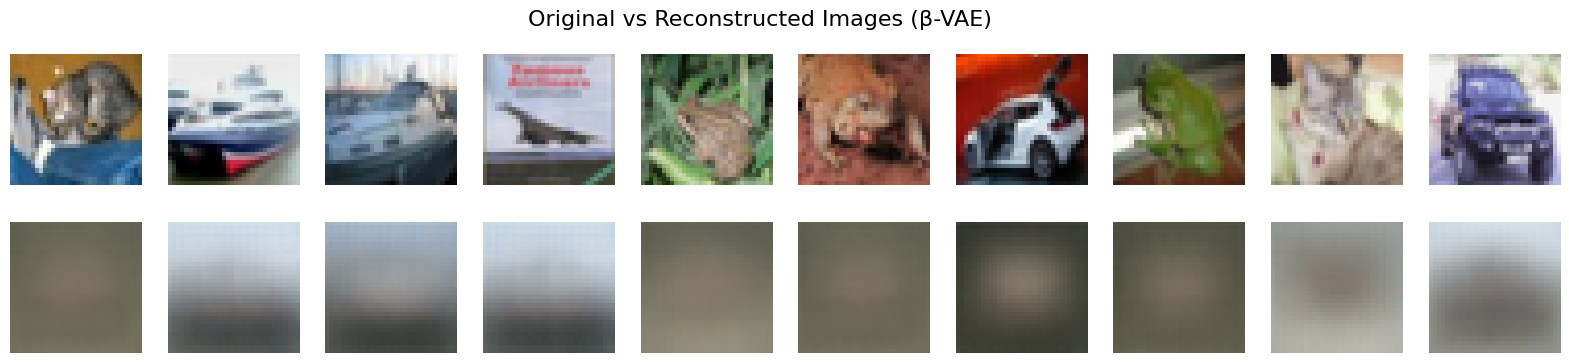

In [17]:

# to display original and reconstructed images
n_display = 10


example_images, _ = next(iter(test_loader))
example_images = example_images[:n_display].to(device)

vae.eval()
with torch.no_grad():
    z_mean, z_log_var, reconstructions = vae(example_images)

# Denormalize images (from [-1, 1] back to [0,1])
example_images = example_images * 0.5 + 0.5
reconstructions = reconstructions * 0.5 + 0.5

# convert to numpy for plotting
example_images = example_images.permute(0, 2, 3, 1).cpu().numpy()
reconstructions = reconstructions.permute(0, 2, 3, 1).cpu().numpy()


fig, axes = plt.subplots(2, n_display, figsize=(20, 4))
for i in range(n_display):
    # this is to display the original images
    axes[0, i].imshow(example_images[i])
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel("Original", fontsize=12)

    # this is to display the reconstructed images
    axes[1, i].imshow(reconstructions[i])
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel("Reconstructed", fontsize=12)

plt.suptitle("Original vs Reconstructed Images (β-VAE)", fontsize=16)
plt.show()


The latent dimension is too small (2), so the reconstructions of the images are very blurry. This shows that the VAE cannot capture all the details of the CIFAR-10 images with a latent space that small. Increasing the latent dimension would improve reconstruction quality."

  b) Experiment with differentβvalues to analyze how settings ofβ >1,β= 1,  andβ <1 influence the model’s ability to capture interpretable variations.  Identify youroptimalβvalue for disentangling

In [18]:
EMBEDDING_DIM = 100
BETA_VALUES = [0.5, 1.0, 4]  # β <1, β=1, β>1
N_GRID = 12
N_IMAGES = N_GRID * N_GRID  # we need 144 images for the grid

# Function to plot a grid of images
def plot_grid(images, title="", n_grid=N_GRID):
    fig, axes = plt.subplots(n_grid, n_grid, figsize=(15, 15))
    for i in range(n_grid):
        for j in range(n_grid):
            idx = i*n_grid + j
            if idx < images.shape[0]:
                axes[i, j].imshow(images[idx])
            axes[i, j].axis('off')
    plt.suptitle(title, fontsize=18)
    plt.show()

In [19]:
trained_models = {}
for beta in BETA_VALUES:

    model_path = f"./models/vae_beta_{beta}.pth"
    if os.path.exists(model_path):
        print(f"Loading pretrained β-VAE for β={beta}")
        encoder = Encoder_part(embedding_dim=EMBEDDING_DIM).to(device)
        decoder = Decoder_part(embedding_dim=EMBEDDING_DIM).to(device)
        vae = VAE(encoder, decoder, beta=beta).to(device)
        vae.load_state_dict(torch.load(model_path))
    else:
        # Train the model for the differents values of Beta
        print(f"Training β-VAE for β={beta}")
        encoder = Encoder_part(embedding_dim=EMBEDDING_DIM).to(device)
        decoder = Decoder_part(embedding_dim=EMBEDDING_DIM).to(device)
        vae = VAE(encoder, decoder, beta=beta).to(device)
        optimizer = torch.optim.Adam(vae.parameters(), lr=LEARNING_RATE)
        for epoch in range(EPOCHS):
            vae.train()
            for data, _ in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                z_mean, z_log_var, recon = vae(data)
                loss, _, _ = vae.loss(data, recon, z_mean, z_log_var)
                loss.backward()
                optimizer.step()
        torch.save(vae.state_dict(), model_path)  # save for future
    trained_models[beta] = vae


Training β-VAE for β=0.5
Training β-VAE for β=1.0
Training β-VAE for β=4


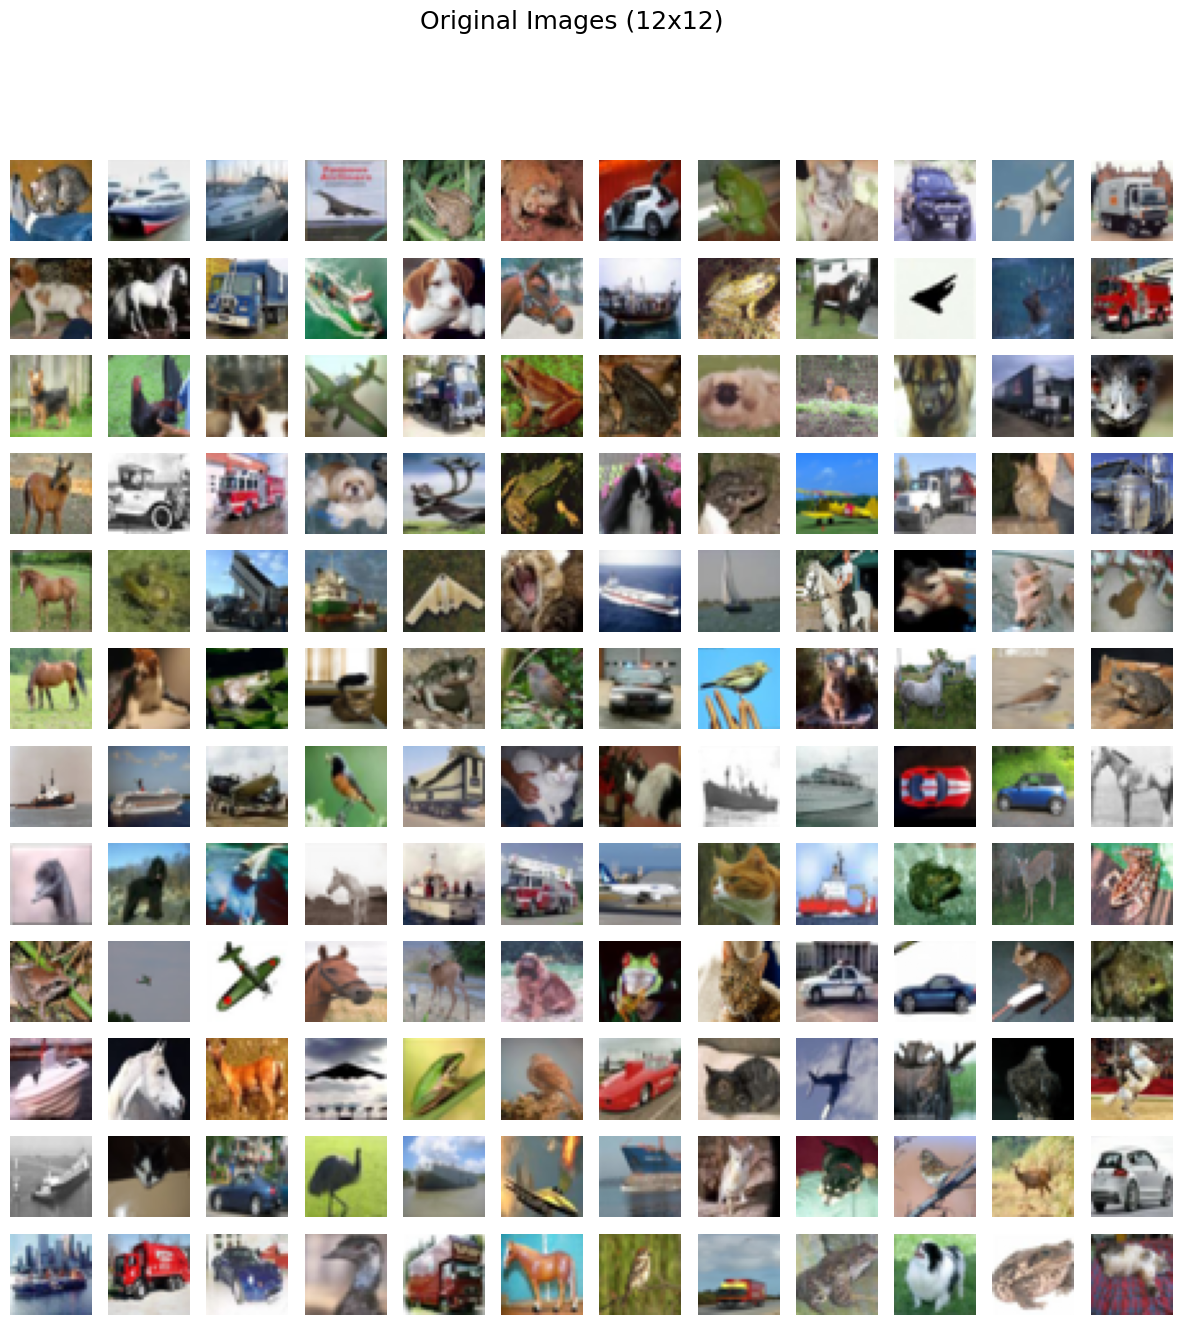

In [20]:
all_test_images = []
for data, _ in test_loader:
    all_test_images.append(data)
    if sum([batch.shape[0] for batch in all_test_images]) >= N_IMAGES:
        break


all_test_images = torch.cat(all_test_images, dim=0)
test_images_grid = all_test_images[:N_IMAGES].to(device)


original_images = (test_images_grid * 0.5 + 0.5).permute(0, 2, 3, 1).cpu().numpy()

# to display original images grid 144 images (12 * 12 grid)
plot_grid(original_images, title="Original Images (12x12)")

In [21]:
N_GRID = 12
N_IMAGES = N_GRID * N_GRID  # 144 images

# to Collect 144 images
all_test_images = []
for data, _ in test_loader:
    all_test_images.append(data)
    if sum([batch.shape[0] for batch in all_test_images]) >= N_IMAGES:
        break

# Concatenate and slice exactly 144 images
test_images_grid = torch.cat(all_test_images, dim=0)[:N_IMAGES].to(device)
reconstructed_images = {}
for beta, vae in trained_models.items():
    vae.eval()
    with torch.no_grad():
        _, _, recon = vae(test_images_grid)
        recon_images = (recon * 0.5 + 0.5).permute(0,2,3,1).cpu().numpy()
        reconstructed_images[beta] = recon_images


In [22]:
#to display the reconstructions using the beta_values
for beta in BETA_VALUES:
    plot_grid(reconstructed_images[beta], title=f"β-VAE Reconstructions (β={beta})")


Output hidden; open in https://colab.research.google.com to view.

Question C

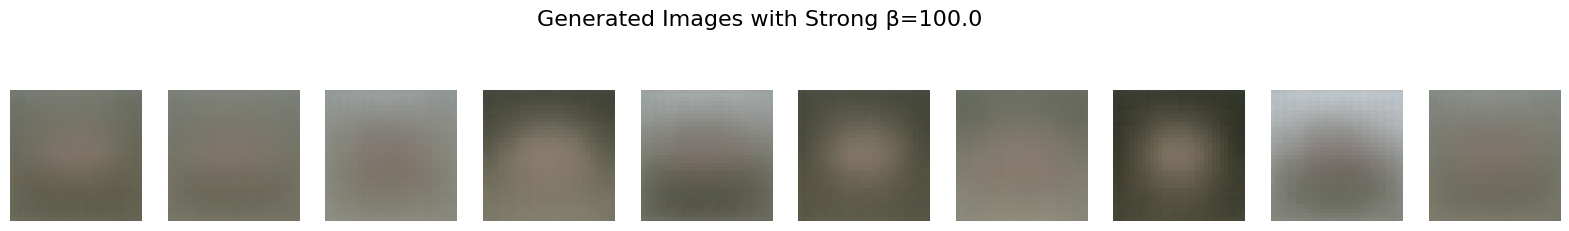

In [23]:
# Part (c)

STRONG_BETA = 100.0
N_DISPLAY = 10

# Initialize models
encoder = Encoder_part(embedding_dim=EMBEDDING_DIM).to(device)
decoder = Decoder_part(embedding_dim=EMBEDDING_DIM).to(device)
vae = VAE(encoder, decoder, beta=STRONG_BETA).to(device)

optimizer = torch.optim.Adam(vae.parameters(), lr=LEARNING_RATE)

#training
for epoch in range(EPOCHS):
    vae.train()
    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        z_mean, z_log_var, recon = vae(data)
        loss, _, _ = vae.loss(data, recon, z_mean, z_log_var)
        loss.backward()
        optimizer.step()

# Generate 10 images
vae.eval()
with torch.no_grad():

    z = torch.randn(N_DISPLAY, EMBEDDING_DIM).to(device)
    generated_images = decoder(z)


generated_images = (generated_images * 0.5 + 0.5).permute(0, 2, 3, 1).cpu().numpy()

# Plot
fig, axes = plt.subplots(1, N_DISPLAY, figsize=(20, 3))
for i in range(N_DISPLAY):
    axes[i].imshow(generated_images[i])
    axes[i].axis('off')
plt.suptitle(f"Generated Images with Strong β={STRONG_BETA}", fontsize=16)
plt.show()
